**Clickbait Classification**

**Environment setup & imports**

In [ ]:
#Environment & imports
import os
import re
import string
import pandas as pd
import numpy as np
from collections import Counter
# Visualization
import matplotlib.pyplot as plt

# NLTK & downloads
import nltk
nltk_data_needed = [
    "punkt",            # tokenizers
    "wordnet",          # lemmatizer
    "omw-1.4",          # wordnet multilingual (for lemmatizer)
    "averaged_perceptron_tagger", # POS tagging
    "maxent_ne_chunker",
    "words",            # for NER chunker
    "stopwords"
]
for pkg in nltk_data_needed:
    try:
        nltk.data.find(pkg)
    except LookupError:
        nltk.download(pkg)
#Remove common words; support lemmatization.
from nltk.corpus import stopwords, wordnet
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag, ne_chunk
from nltk.chunk import RegexpParser

# sklearn & ML
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB

import joblib
print("Imports done.")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping chunkers/maxent_ne_chunker.zip.
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Unzipping corpora/words.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Imports done.


**Load dataset and print basic info (auto-detect text & label)**

In [ ]:
# Cell 2 - Load dataset
DATA_PATH = "clickbait_data.csv"

df = pd.read_csv(DATA_PATH)
print("Loaded dataframe shape:", df.shape)
display(df.head(5))
#Lists all column names and datatype
print("\nColumns:\n", df.columns.tolist())
print("\nDtypes:\n", df.dtypes)

# Auto-detect text column: prefer common names, else first object/string column
possible_text_cols = ["text", "content", "sentence", "sentence_text", "title", "headline"]
#Finds columns containing text
text_col_candidates = [c for c in df.columns if df[c].dtype == object]
TEXT_COL = None
#Selects the most likely text column automatically
for name in possible_text_cols:
    if name in df.columns:
        TEXT_COL = name
        break
if TEXT_COL is None:
    TEXT_COL = text_col_candidates[0] if text_col_candidates else None

# Auto-detect label column: prefer 'label', 'target', 'class', else numeric/binary
possible_label_cols = ["label", "target", "class", "is_clickbait", "clickbait"]
LABEL_COL = None
for name in possible_label_cols:
    if name in df.columns:
        LABEL_COL = name
        break
if LABEL_COL is None:
    # find numeric or object with small number of unique values
    for c in df.columns:
        if c == TEXT_COL:
            continue
        if df[c].nunique() <= 10:
            LABEL_COL = c
            break

print(f"\nAuto-detected TEXT_COL = {TEXT_COL}, LABEL_COL = {LABEL_COL}")
if TEXT_COL is None or LABEL_COL is None:
    raise ValueError("Could not auto-detect text or label columns. Please set TEXT_COL and LABEL_COL manually.")

Loaded dataframe shape: (32000, 2)


,headline,clickbait
0,Should I Get Bings,1
1,Which TV Female Friend Group Do You Belong In,1
2,"The New ""Star Wars: The Force Awakens"" Trailer...",1
3,"This Vine Of New York On ""Celebrity Big Brothe...",1
4,A Couple Did A Stunning Photo Shoot With Their...,1



Columns:
 ['headline', 'clickbait']

Dtypes:
 headline     object
clickbait     int64
dtype: object

Auto-detected TEXT_COL = headline, LABEL_COL = clickbait


**Basic cleaning + printing dataset selection**

In [ ]:
# Cell 3 - Basic cleaning & ensure text is str
# Keeps only the text and label columns
df = df[[TEXT_COL, LABEL_COL]].copy()
df = df.dropna(subset=[TEXT_COL, LABEL_COL]).reset_index(drop=True)
df[TEXT_COL] = df[TEXT_COL].astype(str)
df[LABEL_COL] = df[LABEL_COL].astype(str)  # convert labels to str to avoid type mix-ups
print("After dropping NA:", df.shape)
print("Label distribution:")
print(df[LABEL_COL].value_counts())
display(df.sample(5, random_state=42))

After dropping NA: (32000, 2)
Label distribution:
clickbait
0    16001
1    15999
Name: count, dtype: int64


,headline,clickbait
23100,Filipino activist arrested for disrupting Mani...,0
17362,"International Board fixes soccer field size, h...",0
8993,24 Rules For Women On A First Date With A Man,1
19566,Political fallout from the sacking of Professo...,0
3798,"Which ""Clueless"" Character Are You Based On Yo...",1


**Operations on text corpus: global stats & sample sentences**

In [ ]:
# Cell 4 - Corpus operations: sizes, avg length etc.
df["char_len"] = df[TEXT_COL].apply(len)
df["word_count"] = df[TEXT_COL].apply(lambda s: len(word_tokenize(s)))
print("Corpus total examples:", len(df))
print("Character length - mean, min, max:", df["char_len"].mean(), df["char_len"].min(), df["char_len"].max())
print("Word count - mean, min, max:", df["word_count"].mean(), df["word_count"].min(), df["word_count"].max())

# Top 5 longest rows by words
print("\nTop 5 longest by word count:")
display(df.sort_values("word_count", ascending=False).head(5)[[TEXT_COL, "word_count"]])

# Show 5 random samples
print("\nRandom samples:")
display(df.sample(5, random_state=1)[[TEXT_COL, LABEL_COL]])

Corpus total examples: 32000
Character length - mean, min, max: 53.7970625 6 135
Word count - mean, min, max: 9.6133125 1 27

Top 5 longest by word count:


,headline,word_count
11513,This Video Of A Girl Lip Syncing To A 2008 Sou...,27
9003,"Scott Disick Said He'd ""For Sure"" Kill Kim Kar...",26
638,"P. Diddy's ""I Need A Girl (Part One)"" Was The ...",24
29356,"ITV fined A$3000 for cruelty to rat on ""I'm A ...",23
7230,Your Weekly Gossip Roundup: Justin Long And Am...,23



Random samples:


,headline,clickbait
13667,Everyone Stop And Appreciate Zac Efron Touchin...,1
1978,Are You Ready To Sync Your Vagina With Your Sm...,1
1428,25 Insanely Delicious Things To Make With 3 In...,1
17621,MGM Mirage Reaches Deal on Las Vegas Project,0
3203,This Is Why Soy Milk Goes Funny In Your Coffee,1


**Tokenization (sentence + word tokenization)**

In [ ]:
# Cell 5 - Tokenization examples and helper functions
sample_text = df[TEXT_COL].iloc[0]
print("Sample text:\n", sample_text)
print("\nSentence tokenization:")
print(sent_tokenize(sample_text))
print("\nWord tokenization:")
print(word_tokenize(sample_text))

# Define reusable tokenization function
def tokenize_text(text):
    return word_tokenize(text)

# Add tokenized column (word tokens)
df["tokens"] = df[TEXT_COL].apply(tokenize_text)
display(df[[TEXT_COL, "tokens"]].head(3))

Sample text:
 Should I Get Bings

Sentence tokenization:
['Should I Get Bings']

Word tokenization:
['Should', 'I', 'Get', 'Bings']


,headline,tokens
0,Should I Get Bings,"[Should, I, Get, Bings]"
1,Which TV Female Friend Group Do You Belong In,"[Which, TV, Female, Friend, Group, Do, You, Be..."
2,"The New ""Star Wars: The Force Awakens"" Trailer...","[The, New, ``, Star, Wars, :, The, Force, Awak..."


**lowercase conversion**

In [ ]:
# Cell 6 - Lowercasing tokens and creating lowercase text column
df["text_lower"] = df[TEXT_COL].str.lower()
df["tokens_lower"] = df["tokens"].apply(lambda toks: [t.lower() for t in toks])
display(df[[TEXT_COL, "text_lower", "tokens_lower"]].head(3))

,headline,text_lower,tokens_lower
0,Should I Get Bings,should i get bings,"[should, i, get, bings]"
1,Which TV Female Friend Group Do You Belong In,which tv female friend group do you belong in,"[which, tv, female, friend, group, do, you, be..."
2,"The New ""Star Wars: The Force Awakens"" Trailer...","the new ""star wars: the force awakens"" trailer...","[the, new, ``, star, wars, :, the, force, awak..."


**Frequency distribution (global & per-label)**

Top 30 words overall:
[('to', 6656), ('in', 6473), ('the', 6393), ('you', 5562), ('of', 5102), ('a', 3992), ('for', 3168), ('and', 2822), ('on', 2769), ('your', 2580), ('are', 2164), ('is', 2156), ('that', 2074), ('this', 1859), ('with', 1610), ('at', 1551), ('will', 1382), ('from', 1358), ('what', 1345), ('new', 1244), ('about', 1160), ('who', 1104), ('people', 1018), ('things', 1000), ('how', 954), ('which', 904), ('we', 874), ('it', 858), ('us', 836), ('as', 834)]

Top words for label=1:
[('you', 5539), ('the', 4973), ('to', 3239), ('a', 2627), ('your', 2540), ('of', 2435), ('are', 1994), ('that', 1950), ('in', 1920), ('this', 1811), ('is', 1654), ('and', 1652), ('on', 1458), ('for', 1397), ('what', 1326)]

Top words for label=0:
[('in', 4553), ('to', 3417), ('of', 2667), ('for', 1771), ('the', 1420), ('a', 1365), ('on', 1311), ('and', 1170), ('at', 1064), ('new', 802), ('after', 655), ('with', 650), ('us', 638), ('as', 545), ('by', 539)]


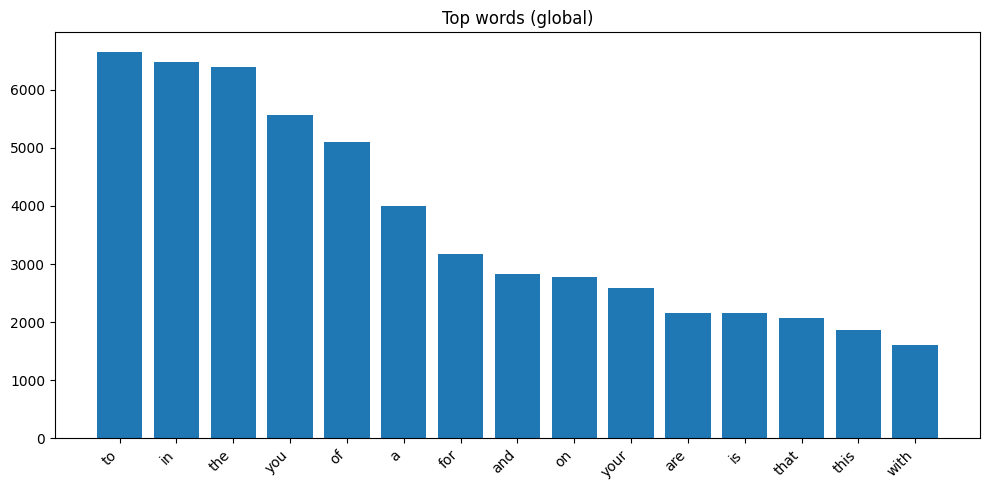

In [ ]:
# Cell 7 - Frequency distribution (top words)
all_words = [w for toks in df["tokens_lower"] for w in toks if w.isalpha()]
freq = Counter(all_words)
top_n = 30
print(f"Top {top_n} words overall:")
print(freq.most_common(top_n))

# Frequency per label (for binary/multi classes)
label_values = df[LABEL_COL].unique()
for lab in label_values:
    words_lab = [w for toks in df[df[LABEL_COL]==lab]["tokens_lower"] for w in toks if w.isalpha()]
    freq_lab = Counter(words_lab)
    print(f"\nTop words for label={lab}:")
    print(freq_lab.most_common(15))

# Simple bar plot of top words
top_items = freq.most_common(15)
words, counts = zip(*top_items)
plt.figure(figsize=(10,5))
plt.bar(words, counts)
plt.xticks(rotation=45, ha="right")
plt.title("Top words (global)")
plt.tight_layout()
plt.show()

**Stop words removal (NLTK) and removing stop words from text**

In [ ]:
# Cell 8 - Remove NLTK stopwords
nltk_stop_words = set(stopwords.words("english"))
print("Number of NLTK stopwords:", len(nltk_stop_words))
print("Sample stopwords:", list(nltk_stop_words)[:10])

def remove_stopwords_from_tokens(tokens, stopset=nltk_stop_words):
    return [t for t in tokens if t.lower() not in stopset and t.isalpha()]

df["tokens_nostop"] = df["tokens_lower"].apply(remove_stopwords_from_tokens)
display(df[[TEXT_COL, "tokens_lower", "tokens_nostop"]].head(3))

Number of NLTK stopwords: 198
Sample stopwords: ['wasn', 'is', 'him', "you'd", 'itself', 'does', "aren't", 'why', 'm', 'be']


,headline,tokens_lower,tokens_nostop
0,Should I Get Bings,"[should, i, get, bings]","[get, bings]"
1,Which TV Female Friend Group Do You Belong In,"[which, tv, female, friend, group, do, you, be...","[tv, female, friend, group, belong]"
2,"The New ""Star Wars: The Force Awakens"" Trailer...","[the, new, ``, star, wars, :, the, force, awak...","[new, star, wars, force, awakens, trailer, giv..."


**Stemming (PorterStemmer)**

In [ ]:
# Cell 9 - Stemming
ps = PorterStemmer()
def stem_tokens(tokens):
    return [ps.stem(t) for t in tokens]

df["tokens_stemmed"] = df["tokens_nostop"].apply(stem_tokens)
display(df[[TEXT_COL, "tokens_nostop", "tokens_stemmed"]].head(3))

,headline,tokens_nostop,tokens_stemmed
0,Should I Get Bings,"[get, bings]","[get, bing]"
1,Which TV Female Friend Group Do You Belong In,"[tv, female, friend, group, belong]","[tv, femal, friend, group, belong]"
2,"The New ""Star Wars: The Force Awakens"" Trailer...","[new, star, wars, force, awakens, trailer, giv...","[new, star, war, forc, awaken, trailer, give, ..."


**Lemmatization (WordNet) with POS-aware helper**

In [ ]:
# Cell 10 - Lemmatization with POS mapping
wnl = WordNetLemmatizer()

def nltk_pos_to_wordnet_pos(nltk_pos_tag):
    if nltk_pos_tag.startswith('J'):
        return wordnet.ADJ
    elif nltk_pos_tag.startswith('V'):
        return wordnet.VERB
    elif nltk_pos_tag.startswith('N'):
        return wordnet.NOUN
    elif nltk_pos_tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

def lemmatize_tokens(tokens):
    pos_tags = pos_tag(tokens)
    lems = []
    for token, p in pos_tags:
        wn_pos = nltk_pos_to_wordnet_pos(p)
        lems.append(wnl.lemmatize(token, wn_pos))
    return lems

# Example: add lemmatized column (applied on tokens_nostop)
df["tokens_lemmatized"] = df["tokens_nostop"].apply(lemmatize_tokens)
display(df[[TEXT_COL, "tokens_nostop", "tokens_lemmatized"]].head(3))

,headline,tokens_nostop,tokens_lemmatized
0,Should I Get Bings,"[get, bings]","[get, bings]"
1,Which TV Female Friend Group Do You Belong In,"[tv, female, friend, group, belong]","[tv, female, friend, group, belong]"
2,"The New ""Star Wars: The Force Awakens"" Trailer...","[new, star, wars, force, awakens, trailer, giv...","[new, star, war, force, awakens, trailer, give..."


**POS Tagging**

In [ ]:
# Cell 11 - POS tagging examples
df["pos_tags"] = df["tokens_nostop"].apply(pos_tag)
print("Sample POS tags (first row):")
print(df["pos_tags"].iloc[0][:30])

Sample POS tags (first row):
[('get', 'VB'), ('bings', 'NNS')]


**Parse tree generation (chunking using RegexpParser)**

In [ ]:
# Cell 12 - Parse tree generation with a simple noun-phrase grammar
grammar = r"""
  NP: {<DT|PP\$>?<JJ>*<NN.*>+}   # chunk determiner/possessive, adjectives and nouns
  VP: {<VB.*><NP|PP|CLAUSE>+$}   # chunk verbs and their arguments
"""
chunk_parser = RegexpParser(grammar)

# parse first 3 examples and print tree
for i in range(min(3, len(df))):
    tags = df["pos_tags"].iloc[i]
    tree = chunk_parser.parse(tags)
    print(f"\nParsed tree for row {i}:")
    print(tree)


Parsed tree for row 0:
(S (VP get/VB (NP bings/NNS)))

Parsed tree for row 1:
(S (NP tv/NN female/NN friend/NN group/NN) belong/VBD)

Parsed tree for row 2:
(S
  (NP new/JJ star/NN wars/NNS)
  force/VBP
  (NP awakens/NNS)
  (VP trailer/VBP (NP give/JJ chills/NNS)))


**Named Entity Recognition (NE chunking)**

In [ ]:
# Cell 13 - Named Entity Recognition (FAST version)

def extract_named_entities(tokens):
    tags = pos_tag(tokens)
    tree = ne_chunk(tags, binary=False)
    named_entities = []
    for subtree in tree:
        if hasattr(subtree, 'label'):
            entity_name = " ".join([leaf[0] for leaf in subtree.leaves()])
            entity_type = subtree.label()
            named_entities.append((entity_name, entity_type))
    return named_entities

# --- Only process a small sample: change N if needed ---
N = 5  # you can increase to 10 or 20 if your dataset is small
sample_df = df.head(N).copy()

sample_df["named_entities"] = sample_df["tokens_nostop"].apply(extract_named_entities)

print(f"Showing NER for first {N} rows only:")
display(sample_df[[TEXT_COL, "named_entities"]])

Showing NER for first 5 rows only:


,headline,named_entities
0,Should I Get Bings,[]
1,Which TV Female Friend Group Do You Belong In,[]
2,"The New ""Star Wars: The Force Awakens"" Trailer...",[]
3,"This Vine Of New York On ""Celebrity Big Brothe...",[]
4,A Couple Did A Stunning Photo Shoot With Their...,[]


**Remove numerical data from text**

In [ ]:
# Cell 14 - Remove numerical data (digits) from original text and make a cleaned text field
def remove_numbers(text):
    return re.sub(r"\d+", "", text)

df["text_no_numbers"] = df[TEXT_COL].apply(remove_numbers)
display(df[[TEXT_COL, "text_no_numbers"]].head(3))

,headline,text_no_numbers
0,Should I Get Bings,Should I Get Bings
1,Which TV Female Friend Group Do You Belong In,Which TV Female Friend Group Do You Belong In
2,"The New ""Star Wars: The Force Awakens"" Trailer...","The New ""Star Wars: The Force Awakens"" Trailer..."


**Remove multiple whitespaces**

In [ ]:
# Cell 15 - Collapse multiple whitespaces into single space and strip
def normalize_whitespace(text):
    return re.sub(r'\s+', ' ', text).strip()

df["text_nowhitespace"] = df["text_no_numbers"].apply(normalize_whitespace)
display(df[[TEXT_COL, "text_no_numbers", "text_nowhitespace"]].head(3))

,headline,text_no_numbers,text_nowhitespace
0,Should I Get Bings,Should I Get Bings,Should I Get Bings
1,Which TV Female Friend Group Do You Belong In,Which TV Female Friend Group Do You Belong In,Which TV Female Friend Group Do You Belong In
2,"The New ""Star Wars: The Force Awakens"" Trailer...","The New ""Star Wars: The Force Awakens"" Trailer...","The New ""Star Wars: The Force Awakens"" Trailer..."


**Prepare final cleaned text column (combining steps) for modeling**

In [ ]:
# Cell 17 - Final cleaned text creation (we'll use text_reduced_dups)
# Optionally you might want to use tokens_lemmatized joined back to text; show both options.

# Create a final lemmatized text (joined tokens)
df["clean_text_lemmatized"] = df["tokens_lemmatized"].apply(lambda toks: " ".join(toks))

# Create a basic cleaned text (from reduced duplicate characters)
if "text_reduced_dups" in df.columns:
    df["clean_text_basic"] = df["text_reduced_dups"].str.lower()
else:
    df["clean_text_basic"] = df[TEXT_COL].str.lower()

# Choose which cleaned version to use (lemma-based is usually better)
FEATURE_TEXT = "clean_text_lemmatized"

print("Using feature text column:", FEATURE_TEXT)
display(df[[TEXT_COL, FEATURE_TEXT]].head(5))

Using feature text column: clean_text_lemmatized


,headline,clean_text_lemmatized
0,Should I Get Bings,get bings
1,Which TV Female Friend Group Do You Belong In,tv female friend group belong
2,"The New ""Star Wars: The Force Awakens"" Trailer...",new star war force awakens trailer give chill
3,"This Vine Of New York On ""Celebrity Big Brothe...",vine new york celebrity big brother fucking pe...
4,A Couple Did A Stunning Photo Shoot With Their...,couple stun photo shoot baby learn inoperable ...


**Train/test split**

In [ ]:
# Cell 18 - Train/test split
RANDOM_STATE = 42
X = df[FEATURE_TEXT].values
y = df[LABEL_COL].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print("Train size:", len(X_train), "Test size:", len(X_test))

Train size: 25600 Test size: 6400


**Model training pipeline and selection (GridSearch over several strong classifiers)**

In [ ]:
# -------------------------------
# Cell 19 — Auto-detect columns
# ------------------------------

import pandas as pd
df = pd.read_csv("clickbait_data.csv")

# AUTO-DETECT columns
possible_text_cols = ["text", "headline", "title", "content"]
possible_label_cols = ["label", "clickbait", "class", "target"]

FEATURE_TEXT = None
TARGET_COL = None

# find text column
for col in possible_text_cols:
    if col in df.columns:
        FEATURE_TEXT = col
        break

# find label column
for col in possible_label_cols:
    if col in df.columns:
        TARGET_COL = col
        break

print("Detected text column:", FEATURE_TEXT)
print("Detected label column:", TARGET_COL)

# --- Now continue only if found ---
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df[FEATURE_TEXT])
y = df[TARGET_COL]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=300)
model.fit(X_train, y_train)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))


Detected text column: headline
Detected label column: clickbait
Accuracy: 0.9634375
Precision: 0.9773798303487277
Recall: 0.9505041246562786
F1 Score: 0.9637546468401487


In [ ]:
# ==============================================
# FAST & CLEAN NLP MODEL: LINEAR SVM (TF-IDF)
# ==============================================

import pandas as pd

# Load your dataset
df = pd.read_csv("clickbait_data.csv")

# Auto-detect text & label columns
possible_text = ["text", "headline", "title", "content"]
possible_label = ["label", "clickbait", "target", "class"]

TEXT_COL = next((c for c in possible_text if c in df.columns), None)
LABEL_COL = next((c for c in possible_label if c in df.columns), None)

print("Detected Text Column:", TEXT_COL)
print("Detected Label Column:", LABEL_COL)

df = df[[TEXT_COL, LABEL_COL]].dropna()

# ==============================================
# TF-IDF + Linear SVM
# ==============================================

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# TF-IDF
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df[TEXT_COL])
y = df[LABEL_COL]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Linear SVM Model
model = LinearSVC()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# ==============================================
# Evaluation Metrics
# ==============================================

print("\n========== Linear SVM Results ==========")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Detected Text Column: headline
Detected Label Column: clickbait

========== Linear SVM Results ==========
Accuracy : 0.97171875
Precision: 0.9771604938271605
Recall   : 0.9673082798655668
F1 Score : 0.9722094272992476


**Gradio app**

In [ ]:
import gradio as gr
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
import pandas as pd

# ------------------------
# Load dataset
# ------------------------
df = pd.read_csv("clickbait_data.csv")

TEXT_COL = "headline"
LABEL_COL = "clickbait"

# ------------------------
# Train Linear SVM model
# ------------------------
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df[TEXT_COL])
y = df[LABEL_COL]

model = LinearSVC()
model.fit(X, y)

# ------------------------
# Prediction function
# ------------------------
def classify_text(input_text):
    text_vec = vectorizer.transform([input_text])
    pred = model.predict(text_vec)[0]

    if pred == 1:
        return "🔥 Clickbait Headline"
    else:
        return "✔️ Not Clickbait"

# ------------------------
# Gradio UI
# ------------------------
app = gr.Interface(
    fn=classify_text,
    inputs=gr.Textbox(lines=3, placeholder="Type a headline..."),
    outputs="text",
    title="Clickbait Headline Detector",
    description="Enter any headline and the model will classify it as Clickbait or Not Clickbait using a trained Linear SVM."
)

app.launch(debug=True)


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://dd3f8372e2dfd8c2e3.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Created dataset file at: .gradio/flagged/dataset1.csv
